<a href="https://colab.research.google.com/github/franciscosrcoelho-coder/Google-Colab/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model

np.random.seed(123)
tf.random.set_seed(123)

In [2]:
!pip install -U scikit-learn

In [3]:
from sklearn.metrics import mean_absolute_percentage_error

In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_percentage_error, \
  mean_absolute_error, r2_score, mean_squared_error

In [5]:
url = 'https://raw.githubusercontent.com/franciscosrcoelho-coder/Google-Colab/refs/heads/main/Data%20Science%20Applications%20Project%20Data.csv'
df = pd.read_csv(url)

In [6]:
# add the date attribute starting from Jan 2000, with a monthly frequency
df['year_month'] = pd.date_range(start='1/2016', end='4/2026', freq='M',
                                    inclusive='both')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        123 non-null    object        
 1   Consumption  123 non-null    int64         
 2   year_month   123 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 3.0+ KB


In [7]:
df=df.drop('Month',axis=1)

In [8]:
df.set_index('year_month', inplace=True)

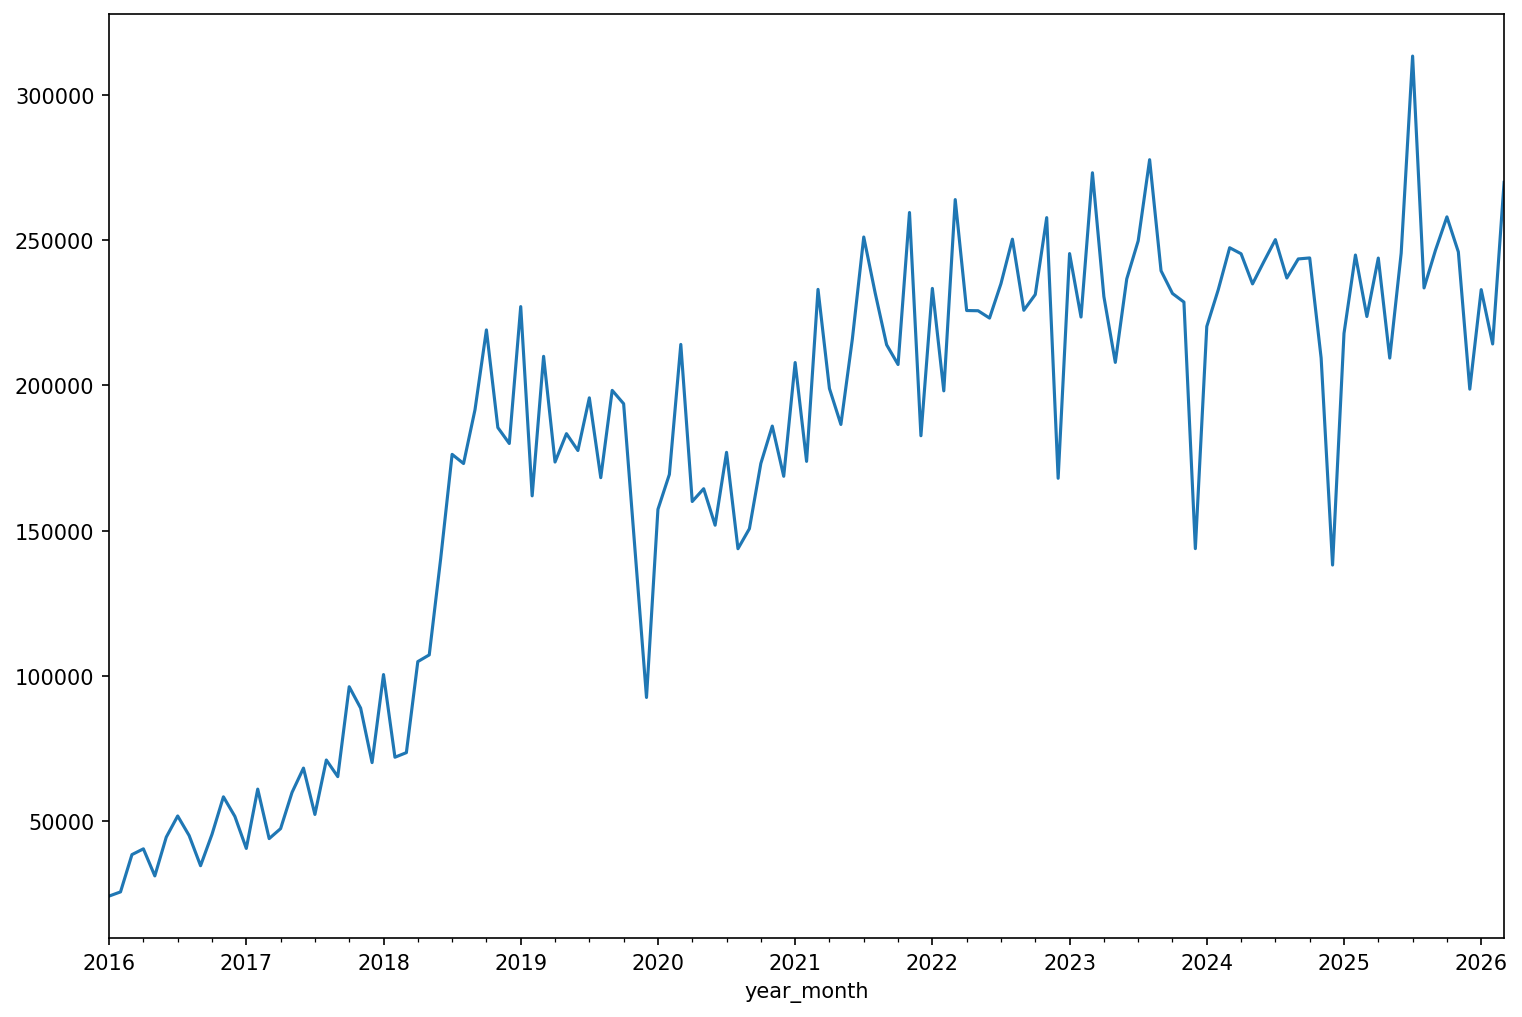

In [9]:
plt.figure(figsize=(12,8),dpi=150)
df['Consumption'].plot();

In [10]:
df.head()

,Consumption
year_month,
2016-01-31,24273
2016-02-29,25715
2016-03-31,38543
2016-04-30,40524
2016-05-31,31222


In [11]:
Ntest = 12
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [12]:
# boolean series to index df rows
train_idx = df.index <= train.index[-1]
test_idx = df.index > train.index[-1]

In [13]:
df['DiffConsumption'] = df['Consumption'].diff()

In [14]:
# Make supervised dataset
series = df['DiffConsumption'].dropna().to_numpy()

T = 10
X = []
Y = []
for t in range(len(series) - T):
  x = series[t:t+T]
  X.append(x)
  y = series[t+T]
  Y.append(y)

X = np.array(X).reshape(-1, T)
Y = np.array(Y)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (112, 10) Y.shape (112,)


In [15]:
Xtrain, Ytrain = X[:-Ntest], Y[:-Ntest]
Xtest, Ytest = X[-Ntest:], Y[-Ntest:]

# **ANN**

In [16]:
# Basic ANN
i = Input(shape=(T,))
x = Dense(32, activation='relu')(i)
x = Dense(1)(x)
model = Model(i, x)

In [17]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [18]:
r = model.fit(
  Xtrain,
  Ytrain,
  epochs=150,
  validation_data=(Xtest, Ytest)
)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 219ms/step - loss: 1327223552.0000 - val_loss: 2765102848.0000
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 1275228544.0000 - val_loss: 2695955456.0000
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 1238024320.0000 - val_loss: 2632536576.0000
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 1205014400.0000 - val_loss: 2574482176.0000
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 1175240192.0000 - val_loss: 2520534784.0000
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 1148116608.0000 - val_loss: 2470849792.0000
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 1123445376.0000 - val_loss: 2424255744.0000
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 1100739072.0000 - val_loss: 2380761856.0000
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 1079828864.0000 - val_loss: 2339862272.0000
Epoch 10/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 1060594752.0000 - val

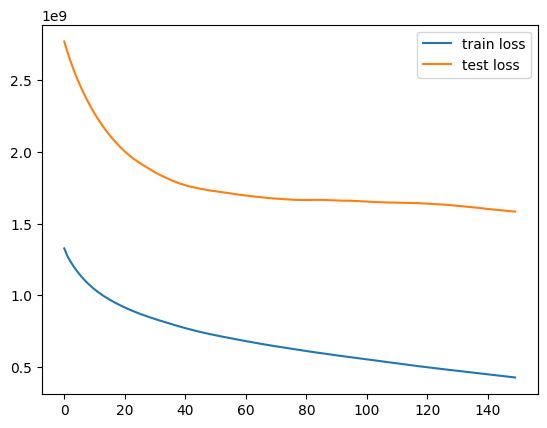

In [19]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [20]:
train_idx[:T+1] = False # first T+1 values are not predictable

In [21]:
Ptrain = model.predict(Xtrain).flatten()
Ptest = model.predict(Xtest).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [22]:
# Store diff predictions
df.loc[train_idx, 'Diff ANN Train Prediction'] = Ptrain
df.loc[test_idx, 'Diff ANN Test Prediction'] = Ptest

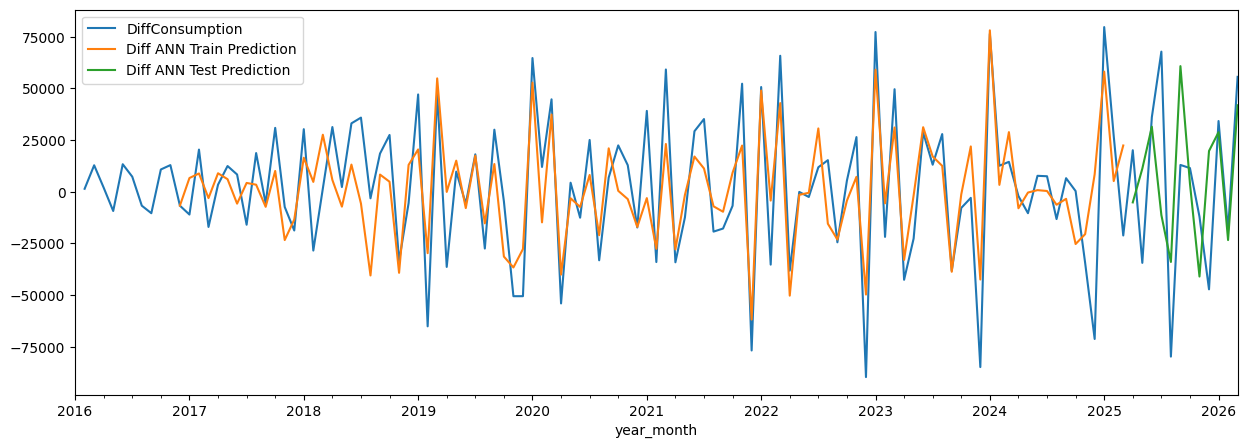

In [23]:
cols = ['DiffConsumption',
        'Diff ANN Train Prediction',
        'Diff ANN Test Prediction']
df[cols].plot(figsize=(15, 5));

In [24]:
# Needed to compute un-differenced predictions
df['ShiftConsumption'] = df['Consumption'].shift(1)
prev = df['ShiftConsumption']

In [25]:
# Last-known train value
last_train = train.iloc[-1]['Consumption']

In [26]:
# 1-step forecast
df.loc[train_idx, '1step_train'] = prev[train_idx] + Ptrain
df.loc[test_idx, '1step_test'] = prev[test_idx] + Ptest

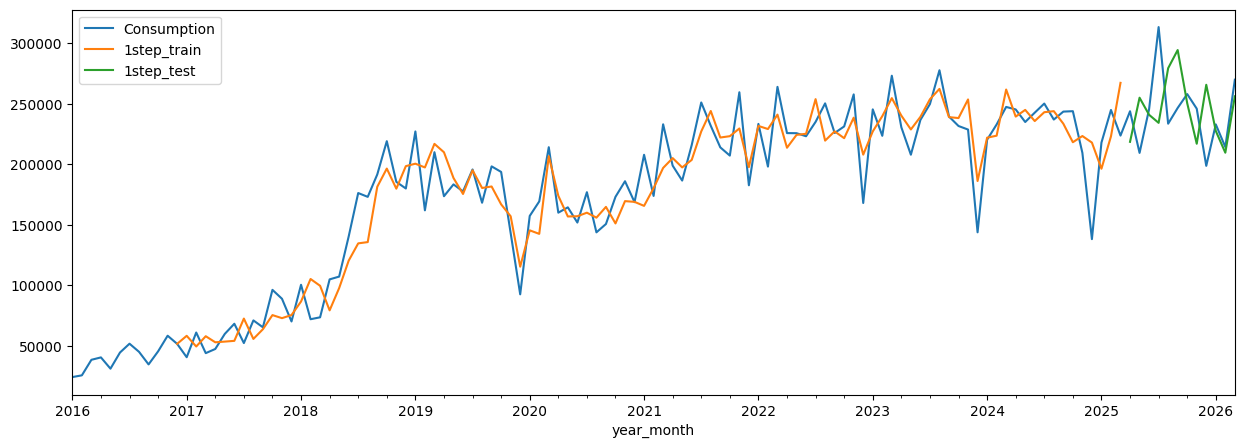

In [27]:
# plot 1-step forecast
df[['Consumption', '1step_train', '1step_test']].plot(figsize=(15, 5));

In [28]:
# multi-step forecast
multistep_predictions = []

# first test input
last_x = Xtest[0]

while len(multistep_predictions) < Ntest:
  p = model.predict(last_x.reshape(1, -1))[0]

  # update the predictions list
  multistep_predictions.append(p)

  # make the new input
  last_x = np.roll(last_x, -1)
  last_x[-1] = p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [29]:
# save multi-step forecast to dataframe
df.loc[test_idx, 'multistep'] = last_train + np.cumsum(multistep_predictions)

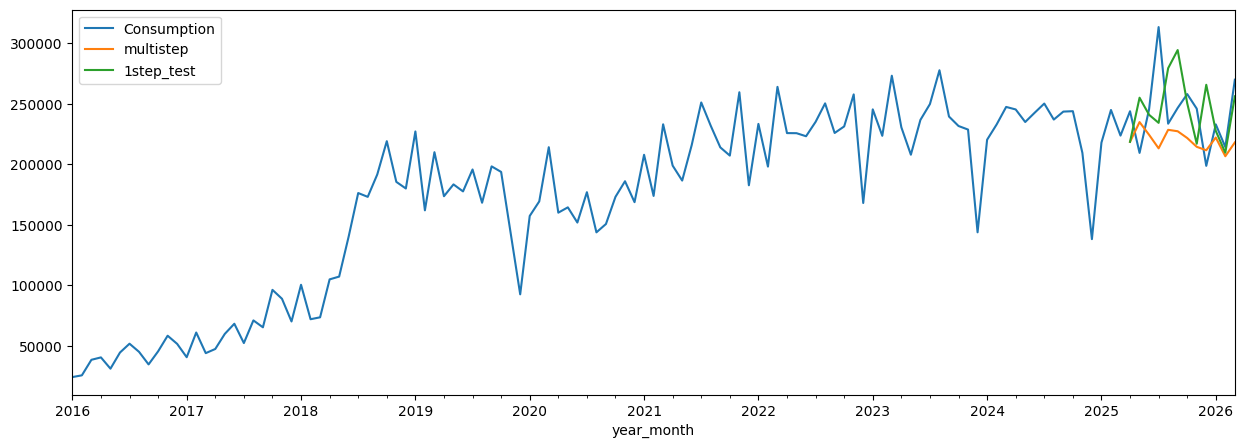

In [30]:
# plot 1-step and multi-step forecast
df[['Consumption', 'multistep', '1step_test']].plot(figsize=(15, 5));

In [31]:
# make multi-output supervised dataset
Tx = T
Ty = Ntest
X = []
Y = []
for t in range(len(series) - Tx - Ty + 1):
  x = series[t:t+Tx]
  X.append(x)
  y = series[t+Tx:t+Tx+Ty]
  Y.append(y)

X = np.array(X).reshape(-1, Tx)
Y = np.array(Y).reshape(-1, Ty)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (101, 10) Y.shape (101, 12)


In [32]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [33]:
# Basic ANN
i = Input(shape=(Tx,))
x = Dense(32, activation='relu')(i)
x = Dense(Ty)(x)
model = Model(i, x)

In [34]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [35]:
r = model.fit(
  Xtrain_m,
  Ytrain_m,
  epochs=150,
  validation_data=(Xtest_m, Ytest_m)
)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 1444445568.0000 - val_loss: 1613483392.0000
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1403383424.0000 - val_loss: 1609993728.0000
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1369586048.0000 - val_loss: 1607715328.0000
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1338563328.0000 - val_loss: 1606581248.0000
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1309829888.0000 - val_loss: 1606206080.0000
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1283198080.0000 - val_loss: 1606240640.0000
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1258317312.0000 - val_loss: 1606525952.0000
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1235217920.0000 - val_loss: 1607135872.0000
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 1213898624.0000 - val_loss: 1608081792.0000
Epoch 10/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1194209792.0000 - val_l

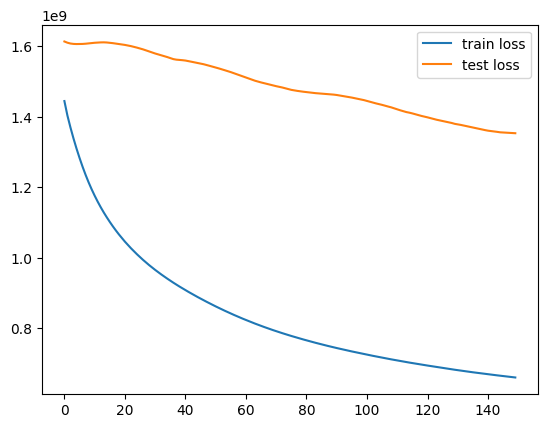

In [36]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [37]:
Ptrain = model.predict(Xtrain_m)
Ptest = model.predict(Xtest_m)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [38]:
Ptrain.shape, Ptest.shape

((100, 12), (1, 12))

In [39]:
Ptrain = Ptrain[:,0]
Ptest = Ptest[0]

In [40]:
# save multi-output forecast to dataframe
df.loc[test_idx, 'multioutput'] = last_train + \
  np.cumsum(Ptest)

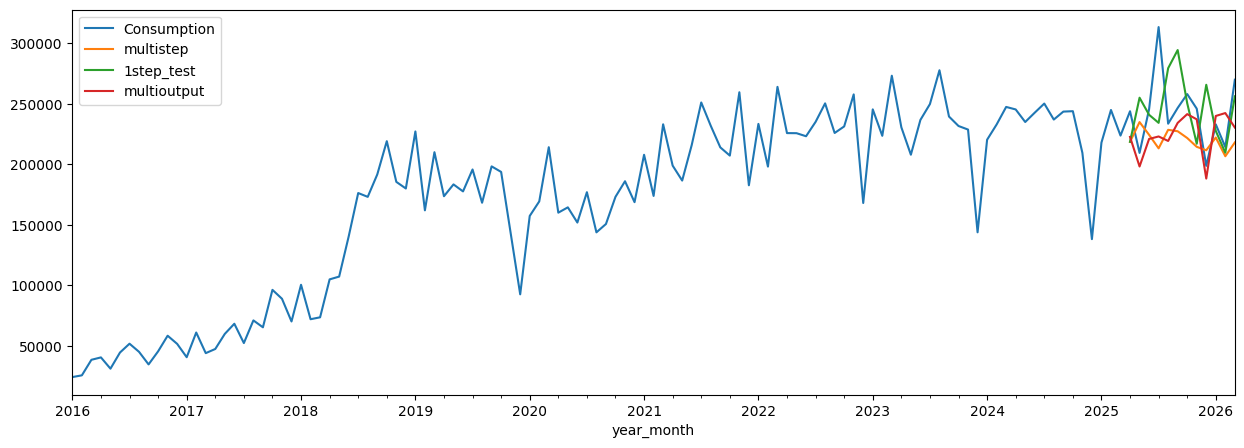

In [41]:
# plot all forecasts
cols = ['Consumption', 'multistep', '1step_test', 'multioutput']
df[cols].plot(figsize=(15, 5));

In [42]:
import math

In [43]:
test_log_pass = df.iloc[-Ntest:]['Consumption']

mae1 = mean_absolute_error(
    test_log_pass, df.loc[test_idx, 'multistep'])
print("multi-step MAE:", mae1)
mape1 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multistep'])
print("multi-step MAPE:", mape1)
rmse1 = math.sqrt(mean_squared_error(test_log_pass, df.loc[test_idx, 'multistep']))
print("multi-step RMSE:", rmse1)
mae2 = mean_absolute_error(
    test_log_pass, df.loc[test_idx, 'multioutput'])
print("multi-output MAE:", mae2)
mape2 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multioutput'])
print("multi-output MAPE:", mape2)
rmse2 = math.sqrt(mean_squared_error(test_log_pass, df.loc[test_idx, 'multioutput']))
print("multi-output RMSE:", rmse2)

multi-step MAE: 28934.191650390625
multi-step MAPE: 0.11151723774604559
multi-step RMSE: 38180.67254940421
multi-output MAE: 23688.803029378254
multi-output MAPE: 0.09166497752924806
multi-output RMSE: 32340.52192966371


# **CNN**

In [44]:
df.head()

,Consumption,DiffConsumption,Diff ANN Train Prediction,Diff ANN Test Prediction,ShiftConsumption,1step_train,1step_test,multistep,multioutput
year_month,,,,,,,,,
2016-01-31,24273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-02-29,25715,1442.0,NaN,NaN,24273.0,NaN,NaN,NaN,NaN
2016-03-31,38543,12828.0,NaN,NaN,25715.0,NaN,NaN,NaN,NaN
2016-04-30,40524,1981.0,NaN,NaN,38543.0,NaN,NaN,NaN,NaN
2016-05-31,31222,-9302.0,NaN,NaN,40524.0,NaN,NaN,NaN,NaN


In [45]:
df.columns

Index(['Consumption', 'DiffConsumption', 'Diff ANN Train Prediction',
       'Diff ANN Test Prediction', 'ShiftConsumption', '1step_train',
       '1step_test', 'multistep', 'multioutput'],
      dtype='object')

In [46]:
df=df.drop(['Diff ANN Train Prediction',
       'Diff ANN Test Prediction', 'ShiftConsumption', '1step_train',
       '1step_test', 'multistep', 'multioutput'],axis=1)

In [47]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.models import Model

In [48]:
# CNN
i = Input(shape=(T, 1))
x = Conv1D(16, 3, activation='relu')(i)
x = MaxPooling1D(2)(x)
x = Conv1D(32, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1)(x)
model = Model(i, x)

In [49]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 8, 16)          │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 32)          │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,665 (6.50 KB)

 Trainable params: 1,665 (6.50 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [51]:
# CNN
i = Input(shape=(T, 1), dtype=tf.float32)
x = Conv1D(16, 3, activation='relu')(i)
x = MaxPooling1D(2)(x)
x = Conv1D(32, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1)(x)
model = Model(i, x)

model.compile(
  loss='mse',
  optimizer='adam',
)

Xtrain_cnn = Xtrain.reshape(-1, T, 1).astype(np.float32)
Ytrain_cnn = Ytrain.astype(np.float32)
Xtest_cnn = Xtest.reshape(-1, T, 1).astype(np.float32)
Ytest_cnn = Ytest.astype(np.float32)

r = model.fit(
  Xtrain_cnn,
  Ytrain_cnn,
  epochs=100,
  validation_data=(Xtest_cnn, Ytest_cnn)
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 1235336448.0000 - val_loss: 2199152640.0000
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1181452800.0000 - val_loss: 2130561024.0000
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1158283648.0000 - val_loss: 2106845568.0000
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1138477824.0000 - val_loss: 2093091328.0000
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1119082880.0000 - val_loss: 2077861504.0000
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1101351040.0000 - val_loss: 2061739392.0000
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1085745280.0000 - val_loss: 2050207744.0000
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1070543104.0000 - val_loss: 2040474240.0000
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1056744960.0000 - val_loss: 2031150592.0000
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1044410944.0000 - val_l

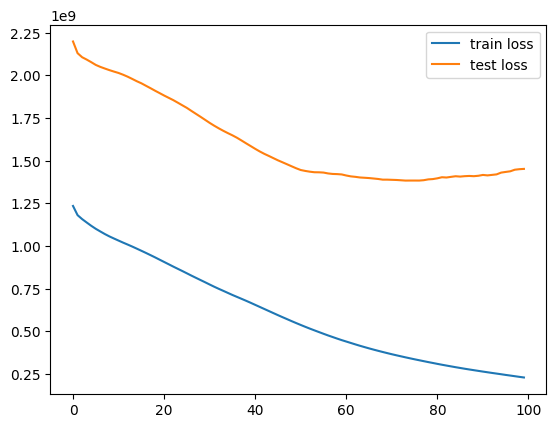

In [52]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [53]:
train_idx[:T+1] = False # first T+1 values are not predictable

In [54]:
Ptrain = model.predict(Xtrain_cnn).flatten()
Ptest = model.predict(Xtest_cnn).flatten()

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [55]:
# Store diff predictions
df.loc[train_idx, 'Diff Train Prediction'] = Ptrain
df.loc[test_idx, 'Diff Test Prediction'] = Ptest

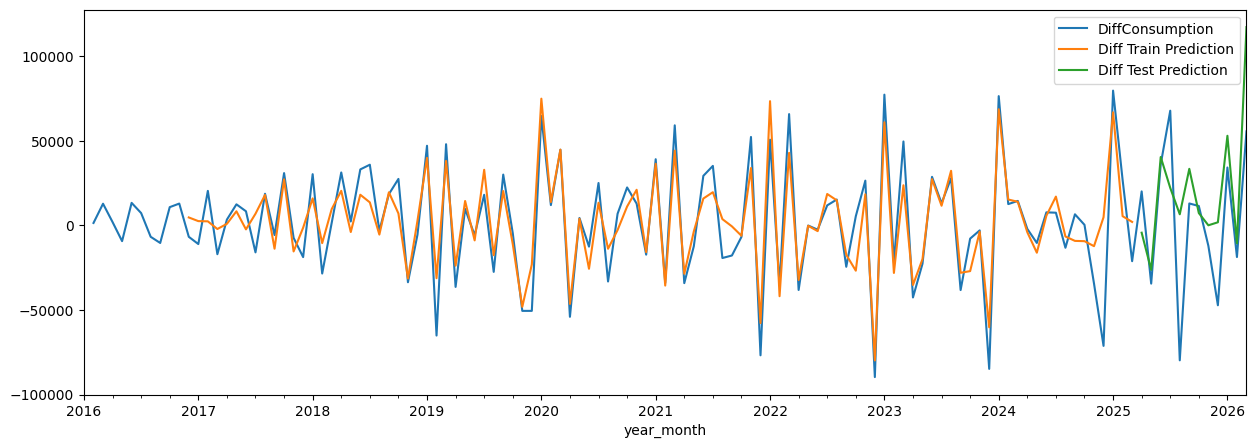

In [56]:
cols = ['DiffConsumption',
        'Diff Train Prediction',
        'Diff Test Prediction']
df[cols].plot(figsize=(15, 5));

In [57]:
# Needed to compute un-differenced predictions
df['ShiftConsumption'] = df['Consumption'].shift(1)
prev = df['ShiftConsumption']

In [58]:
# Last-known train value
last_train = train.iloc[-1]['Consumption']

In [59]:
# 1-step forecast
df.loc[train_idx, '1step_train'] = prev[train_idx] + Ptrain
df.loc[test_idx, '1step_test'] = prev[test_idx] + Ptest

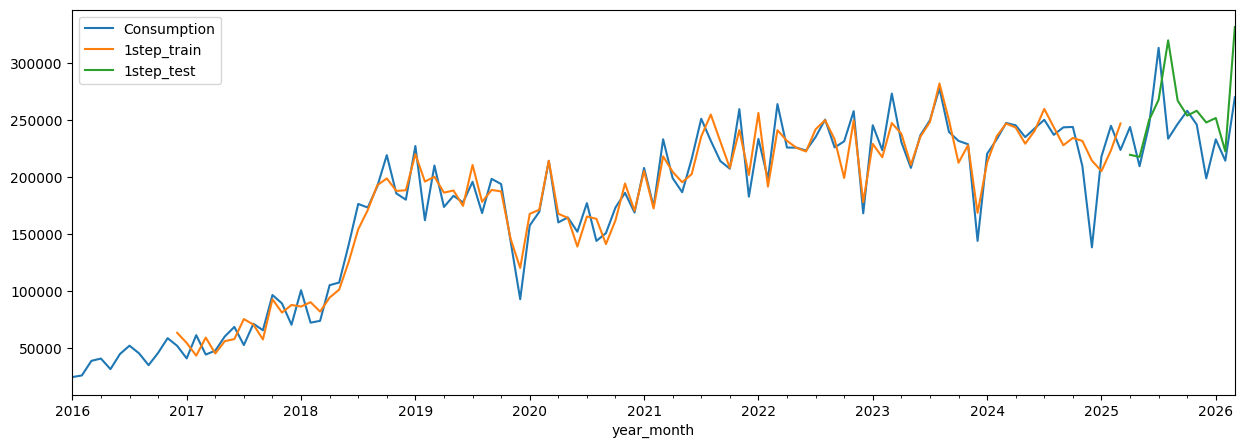

In [60]:
# plot 1-step forecast
df[['Consumption', '1step_train', '1step_test']].plot(figsize=(15, 5));

In [61]:
# multi-step forecast
multistep_predictions = []

# first test input
last_x = Xtest[0]

while len(multistep_predictions) < Ntest:
  p = model.predict(last_x.reshape(1, -1, 1))[0]

  # update the predictions list
  multistep_predictions.append(p)

  # make the new input
  last_x = np.roll(last_x, -1)
  last_x[-1] = p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [62]:
# save multi-step forecast to dataframe
df.loc[test_idx, 'multistep'] = last_train + np.cumsum(multistep_predictions)

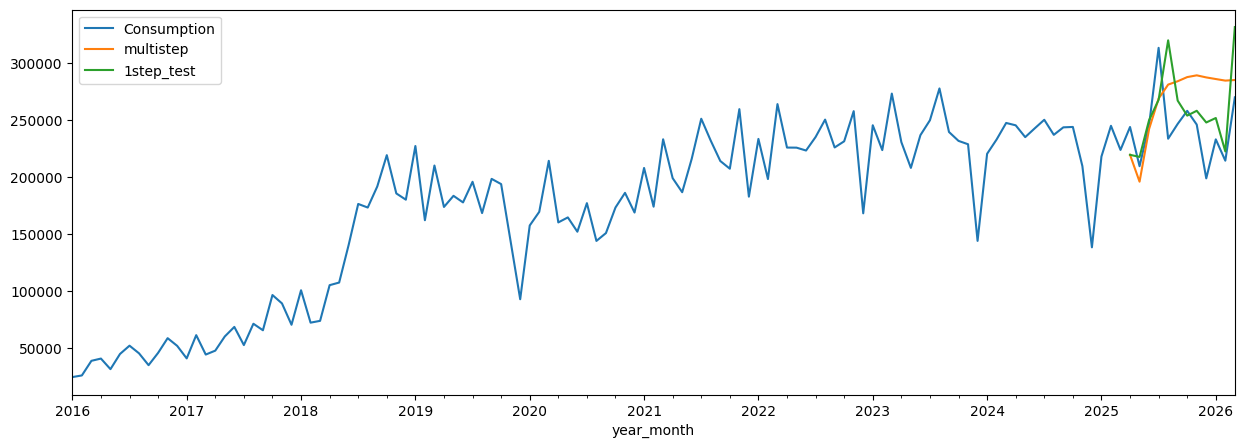

In [63]:
# plot 1-step and multi-step forecast
df[['Consumption', 'multistep', '1step_test']].plot(figsize=(15, 5));

In [64]:
# make multi-output supervised dataset
Tx = T
Ty = Ntest
X = []
Y = []
for t in range(len(series) - Tx - Ty + 1):
  x = series[t:t+Tx]
  X.append(x)
  y = series[t+Tx:t+Tx+Ty]
  Y.append(y)

X = np.array(X).reshape(-1, Tx, 1)
Y = np.array(Y).reshape(-1, Ty)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (101, 10, 1) Y.shape (101, 12)


In [65]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [66]:
# CNN
i = Input(shape=(Tx, 1))
x = Conv1D(16, 3, activation='relu')(i)
x = MaxPooling1D(2)(x)
x = Conv1D(32, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(Ty)(x)
model = Model(i, x)

In [67]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [68]:
r = model.fit(
  Xtrain_m,
  Ytrain_m,
  epochs=200,
  validation_data=(Xtest_m, Ytest_m)
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 1368569216.0000 - val_loss: 1583494144.0000
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1333584384.0000 - val_loss: 1595727872.0000
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1311601792.0000 - val_loss: 1607351680.0000
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1297304832.0000 - val_loss: 1612672384.0000
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1287366144.0000 - val_loss: 1612063872.0000
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1279676416.0000 - val_loss: 1604301440.0000
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1272800256.0000 - val_loss: 1588380672.0000
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1266043392.0000 - val_loss: 1568808832.0000
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1259295872.0000 - val_loss: 1557065088.0000
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1253010816.0000 - val_l

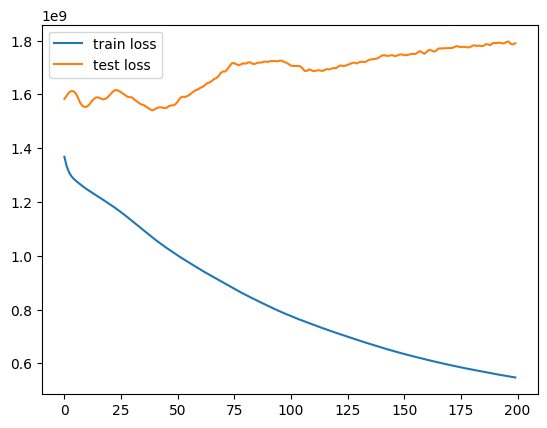

In [69]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [70]:
Ptrain = model.predict(Xtrain_m)
Ptest = model.predict(Xtest_m)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [71]:
Ptrain.shape, Ptest.shape

((100, 12), (1, 12))

In [72]:
Ptrain = Ptrain[:,0]
Ptest = Ptest[0]

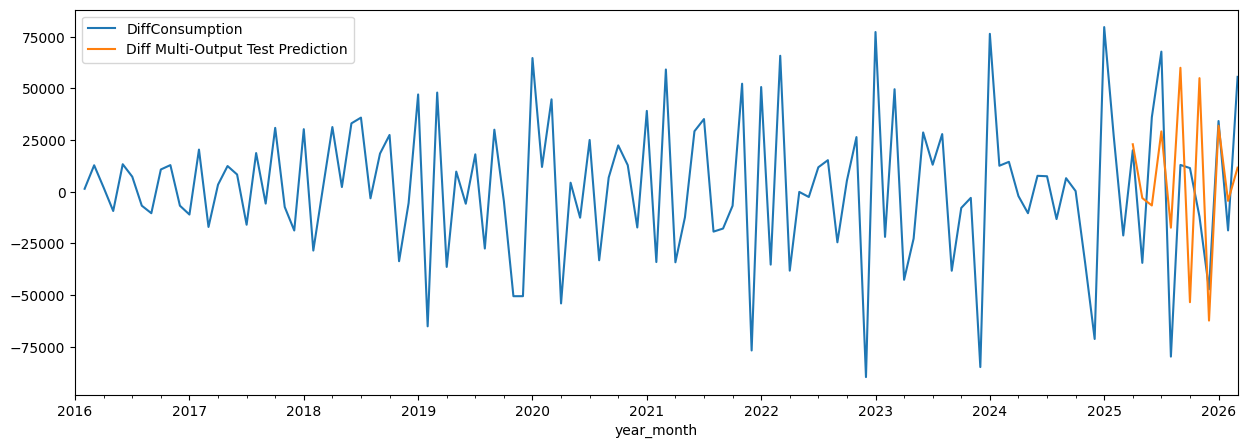

In [73]:
df.loc[test_idx, 'Diff Multi-Output Test Prediction'] = Ptest
cols = ['DiffConsumption', 'Diff Multi-Output Test Prediction']
df[cols].plot(figsize=(15, 5));

In [74]:
# save multi-output forecast to dataframe
df.loc[test_idx, 'multioutput'] = last_train + \
  np.cumsum(Ptest)

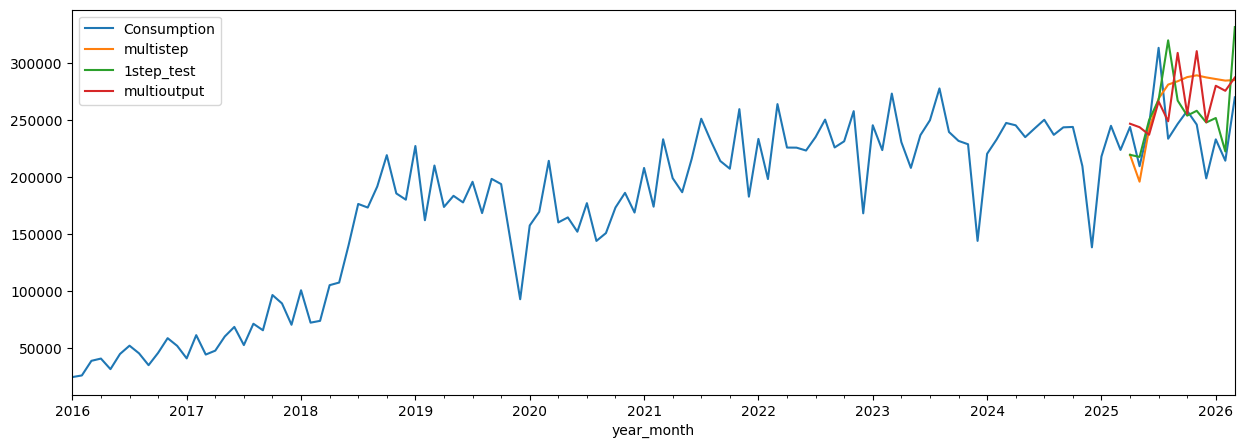

In [75]:
# plot all forecasts
cols = ['Consumption', 'multistep', '1step_test', 'multioutput']
df[cols].plot(figsize=(15, 5));

In [76]:
test_log_pass = df.iloc[-Ntest:]['Consumption']

mae1 = mean_absolute_error(
    test_log_pass, df.loc[test_idx, 'multistep'])
print("multi-step MAE:", mae1)
mape1 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multistep'])
print("multi-step MAPE:", mape1)
rmse1 = math.sqrt(mean_squared_error(test_log_pass, df.loc[test_idx, 'multistep']))
print("multi-step RMSE:", rmse1)
mae2 = mean_absolute_error(
    test_log_pass, df.loc[test_idx, 'multioutput'])
print("multi-output MAE:", mae2)
mape2 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multioutput'])
print("multi-output MAPE:", mape2)
rmse2 = math.sqrt(mean_squared_error(test_log_pass, df.loc[test_idx, 'multioutput']))
print("multi-output RMSE:", rmse2)

multi-step MAE: 39236.680826822914
multi-step MAPE: 0.16874248354037222
multi-step RMSE: 45654.91925404121
multi-output MAE: 34377.022786458336
multi-output MAPE: 0.14599700536728064
multi-output RMSE: 41300.623067633096


## **Auto-Arima**



In [77]:
df.head()

,Consumption,DiffConsumption,Diff Train Prediction,Diff Test Prediction,ShiftConsumption,1step_train,1step_test,multistep,Diff Multi-Output Test Prediction,multioutput
year_month,,,,,,,,,,
2016-01-31,24273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-02-29,25715,1442.0,NaN,NaN,24273.0,NaN,NaN,NaN,NaN,NaN
2016-03-31,38543,12828.0,NaN,NaN,25715.0,NaN,NaN,NaN,NaN,NaN
2016-04-30,40524,1981.0,NaN,NaN,38543.0,NaN,NaN,NaN,NaN,NaN
2016-05-31,31222,-9302.0,NaN,NaN,40524.0,NaN,NaN,NaN,NaN,NaN


In [78]:
df.columns

Index(['Consumption', 'DiffConsumption', 'Diff Train Prediction',
       'Diff Test Prediction', 'ShiftConsumption', '1step_train', '1step_test',
       'multistep', 'Diff Multi-Output Test Prediction', 'multioutput'],
      dtype='object')

In [79]:
df=df.drop(['DiffConsumption', 'Diff Train Prediction',
       'Diff Test Prediction', 'ShiftConsumption', '1step_train', '1step_test',
       'multistep', 'Diff Multi-Output Test Prediction', 'multioutput'],axis=1)

In [80]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.0 MB/s eta 0:00:00


In [81]:
import pmdarima as pm

In [82]:
model = pm.auto_arima(train['Consumption'],
                      trace=True,
                      suppress_warnings=True,
                      seasonal=True, m=12)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=2555.235, Time=1.97 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2606.270, Time=0.07 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2550.973, Time=0.24 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2555.537, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2604.602, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=2581.281, Time=0.08 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=2552.768, Time=0.88 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=2552.904, Time=0.49 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=2558.436, Time=0.30 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=2554.470, Time=3.40 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=2564.976, Time=0.69 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=2551.368, Time=1.18 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=2552.035, Time=0.82 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=2550.707, Time=0.31 sec
 ARIMA(0,1,1)(0,0,0

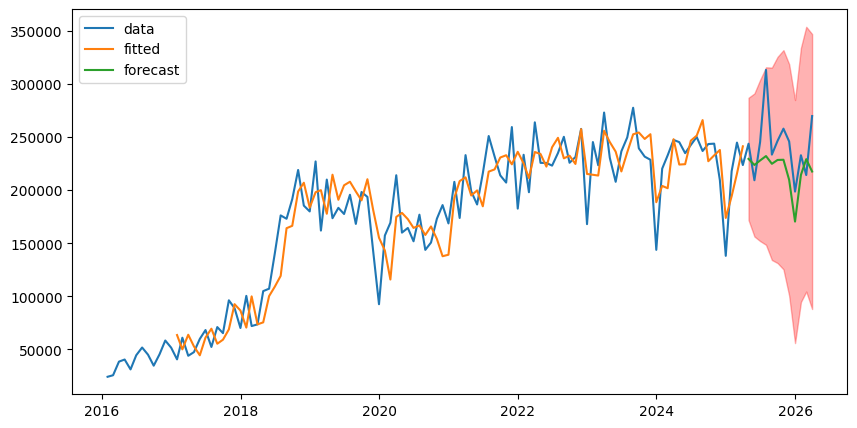

In [83]:
# Since the model is seasonal, we won't plot or predict the first 12
# values (since pmdarima will set them to 0)
train_pred = model.predict_in_sample(start=12, end=-1)
test_pred, confint = model.predict(n_periods=Ntest, return_conf_int=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.index, df['Consumption'], label='data')
ax.plot(train.index[12:], train_pred, label='fitted')
ax.plot(test.index, test_pred, label='forecast')
ax.fill_between(test.index, \
                confint[:,0], confint[:,1], \
                color='red', alpha=0.3)
ax.legend();

In [84]:
mean_absolute_error(test['Consumption'], test_pred)

27793.01606633789

In [85]:
mean_absolute_percentage_error(test['Consumption'], test_pred)

0.10948962661224532

In [86]:
math.sqrt(mean_squared_error(test['Consumption'], test_pred))

34116.86451657382

In [87]:
# Best non-seasonal model
model = pm.auto_arima(train['Consumption'],
                      trace=True,
                      max_p=12, max_q=2, max_order=14,
                      suppress_warnings=True,
                      stepwise=False,
                      seasonal=False)

 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2606.270, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2575.237, Time=0.04 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=2578.557, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2581.281, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2576.578, Time=0.05 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2571.666, Time=0.16 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=2580.723, Time=0.05 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2578.942, Time=0.09 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2572.945, Time=0.22 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=2576.360, Time=0.06 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=2577.205, Time=0.09 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=2579.537, Time=0.16 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=2577.125, Time=0.07 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=2579.066, Time=0.12 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=2576.212, Time=0.26 sec
 ARIMA(5,1

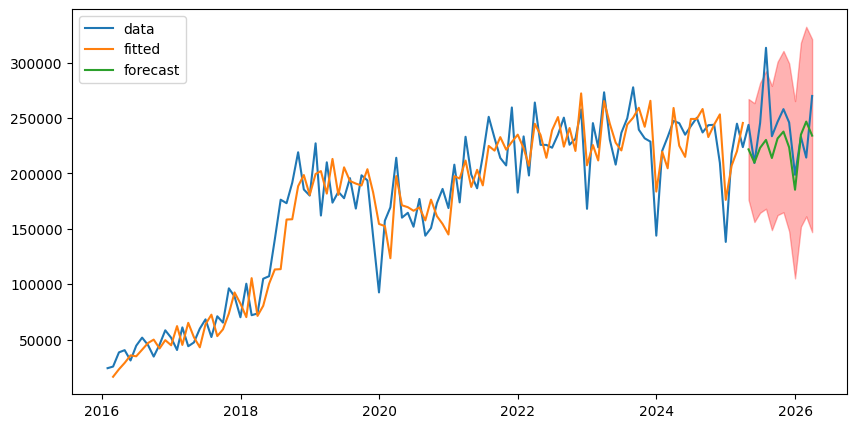

In [88]:
train_pred = model.predict_in_sample(start=1, end=-1)
test_pred, confint = model.predict(n_periods=Ntest, return_conf_int=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.index, df['Consumption'], label='data')
ax.plot(train.index[1:], train_pred, label='fitted')
ax.plot(test.index, test_pred, label='forecast')
ax.fill_between(test.index, \
                confint[:,0], confint[:,1], \
                color='red', alpha=0.3)
ax.legend();

In [89]:
mean_absolute_error(test['Consumption'], test_pred)

24090.491404110013

In [90]:
mean_absolute_percentage_error(test['Consumption'], test_pred)

0.09370082729210212

In [91]:
math.sqrt(mean_squared_error(test['Consumption'], test_pred))

31548.91275618338